In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from scipy.integrate import solve_ivp
import datetime

In [2]:
M = [1, 1, 2] # particle masses (this is actually sqrt(G)*M, but of course we are doing G = 1 here)
#----------

N = len(M) # number of particles in the system
def newtonian_dynamic_2D(t, η):
    # η = [X[0], Y[0], Vx[0], Vy[0], ..., X[N], Y[N], Vx[N], Vy[N]]
    dηdt = np.zeros(4*N, dtype=float)
    for i in range(0, N):
        dηdt[4*i+0] = η[4*i+2]
        dηdt[4*i+1] = η[4*i+3]
        for j in range(0, N):
            if i!=j:
                rij = np.sqrt(np.power(η[4*j]-η[4*i], 2) + np.power(η[4*j+1]-η[4*i+1], 2))
                dηdt[4*i+2] += M[j]*(η[4*j+0]-η[4*i+0])/np.power(rij, 3)
                dηdt[4*i+3] += M[j]*(η[4*j+1]-η[4*i+1])/np.power(rij, 3)
    return dηdt

In [3]:
η0 = [] # Condições iniciais
for i in range(0, 4*N):
    η0.append(np.random.uniform(-1,1))

t_init = 0 # Tempo inicial da simulacao em unidades de sei la, bananas
t_final = 10 # Tempo final da simulacao em unidades de sei la, bananas
t_len = 1000 # Time step de um ponto ao outro
#----------

t_vec = np.linspace(t_init, t_final, t_len)
sol = solve_ivp(newtonian_dynamic_2D, [t_init, t_final], η0, method='RK45', t_eval=t_vec, rtol=1e-8)

In [4]:
X, Y = [], []
for i in range(0, N):
    X.append(sol.y[4*i+0])
    Y.append(sol.y[4*i+1])
X_min, X_max = np.min(np.array(X).flatten()), np.max(np.array(X).flatten())
Y_min, Y_max = np.min(np.array(Y).flatten()), np.max(np.array(Y).flatten())

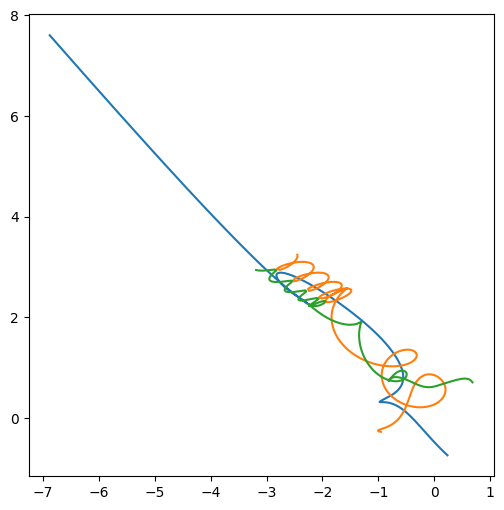

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
for i in range(len(X)):
    ax.plot(X[i],Y[i])

Saved: 20260222-191401.gif (167 frames)


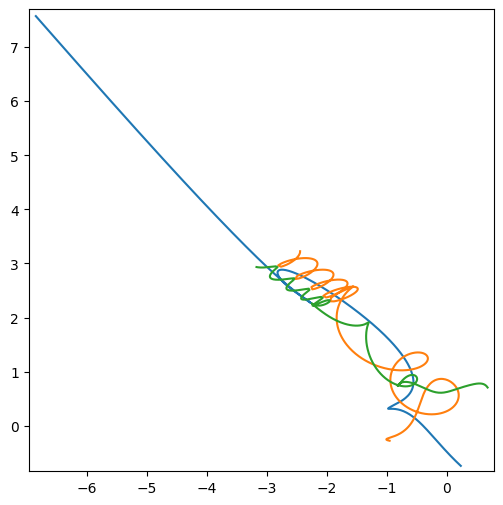

In [6]:
# Use fewer frames for faster GIF (150 frames at 30 fps ≈ 5 s)
n_frames_gif = 150
frame_indices = np.arange(0, t_len, max(1, t_len // n_frames_gif))

fig, ax = plt.subplots(figsize=(6, 6))
canvas = []
for i in range(0, N):
    canvas.append(ax.plot([], [])[0])

lim_tol = 0.1
ax.set_xlim(X_min - lim_tol, X_max + lim_tol)
ax.set_ylim(Y_min - lim_tol, Y_max + lim_tol)

metadata = dict(title='Many_Bodies_Newtonian_Gravity_2D', artist='condekiq')
writer = PillowWriter(fps=30, metadata=metadata)

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
out_path = timestamp + ".gif"
dpi = 80  # lower DPI = faster encoding, smaller file
with writer.saving(fig, out_path, dpi):
    for i in frame_indices:
        for j in range(0, N):
            canvas[j].set_data(X[j][: i + 1], Y[j][: i + 1])
        writer.grab_frame()

print(f"Saved: {out_path} ({len(frame_indices)} frames)")